In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(r"..\Uncleaned dataset\Age_Classification_Statistics_Raw.csv")
print(df.head())
print(df.info())
print(df.describe())

   Year Age_Bracket  Fatal  Non_Fatal_Injury  Grand_Total
0  2017    01 to 17      4               136          140
1  2017    18 to 34    163              6182         6345
2  2017    35 to 51     91              3589         3680
3  2017    52 to 65     37              1115         1152
4  2017    66 above     22               356          378
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Year              48 non-null     int64 
 1   Age_Bracket       48 non-null     object
 2   Fatal             48 non-null     int64 
 3   Non_Fatal_Injury  48 non-null     int64 
 4   Grand_Total       48 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.0+ KB
None
              Year       Fatal  Non_Fatal_Injury   Grand_Total
count    48.000000   48.000000         48.000000     48.000000
mean   2020.500000  115.416667       4883.04166

In [2]:
def unique(dataset):
    print(dataset.nunique())
    print(dataset.unique())
    print(dataset.value_counts())

unique(df['Year'])
unique(df['Age_Bracket'])

8
[2017 2018 2019 2020 2021 2022 2023 2024]
Year
2017    6
2018    6
2019    6
2020    6
2021    6
2022    6
2023    6
2024    6
Name: count, dtype: int64
8
['01 to 17' '18 to 34' '35 to 51' '52 to 65' '66 above' 'Grand Total'
 '0 to 17' '65 above']
Age_Bracket
18 to 34       8
35 to 51       8
52 to 65       8
Grand Total    8
66 above       7
0 to 17        6
01 to 17       2
65 above       1
Name: count, dtype: int64


In [3]:
df = df.drop(columns = 'Grand_Total')
df = df[df['Age_Bracket'] != 'Grand Total']

age_map = {
    '0 to 17':'0-17',
    '01 to 17': '0-17', 
    '18 to 34':'18-34',
    '35 to 51':'35-51',
    '52 to 65':'52-65',
    '65 above':'66+',
    '66 above':'66+'
}
age_mid = {
    '0-17': 9,
    '18-34': 26,
    '35-51': 43,
    '52-65': 58,
    '66+': 75
}
ordinal_map = {
    '0-17': 1,
    '18-34': 2,
    '35-51': 3,
    '52-65': 4,
    '66+': 5
}

age_order = ['0-17', '18-34', '35-51', '52-65', '66+']

df['Age_Bracket'] = df['Age_Bracket'].map(age_map)
df['Age_Bracket_midpoint'] = df['Age_Bracket'].map(age_mid)
df['Age_Bracket_ML'] = df['Age_Bracket'].map(ordinal_map)
df['Age_Bracket_cat'] = pd.Categorical(df['Age_Bracket'], categories=age_order, ordered=True)

In [4]:
unique(df['Age_Bracket'])
unique(df['Age_Bracket_midpoint'])

5
['0-17' '18-34' '35-51' '52-65' '66+']
Age_Bracket
0-17     8
18-34    8
35-51    8
52-65    8
66+      8
Name: count, dtype: int64
5
[ 9 26 43 58 75]
Age_Bracket_midpoint
9     8
26    8
43    8
58    8
75    8
Name: count, dtype: int64


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Fatal'}>],
       [<Axes: title={'center': 'Non_Fatal_Injury'}>,
        <Axes: title={'center': 'Age_Bracket_midpoint'}>],
       [<Axes: title={'center': 'Age_Bracket_ML'}>, <Axes: >]],
      dtype=object)

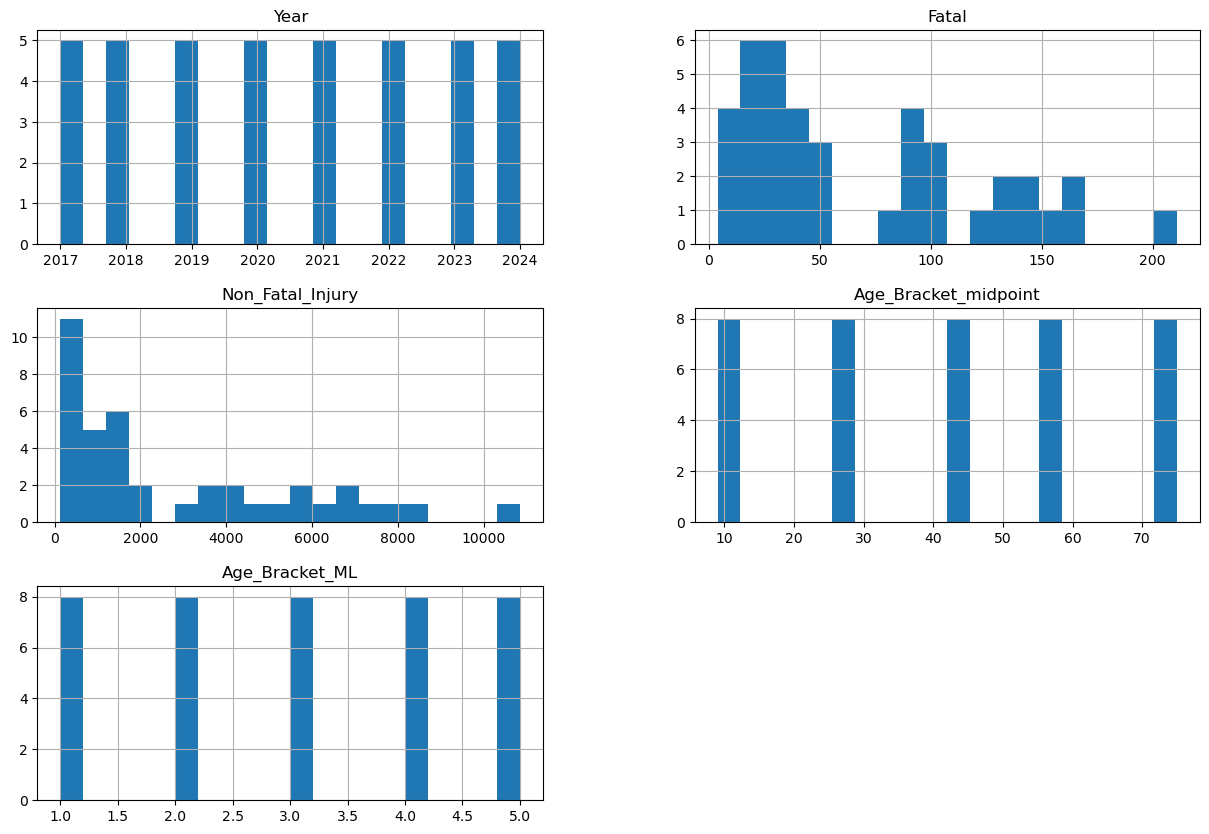

In [5]:
df.hist(figsize=(15, 10), bins=20)

<Figure size 1800x1000 with 0 Axes>

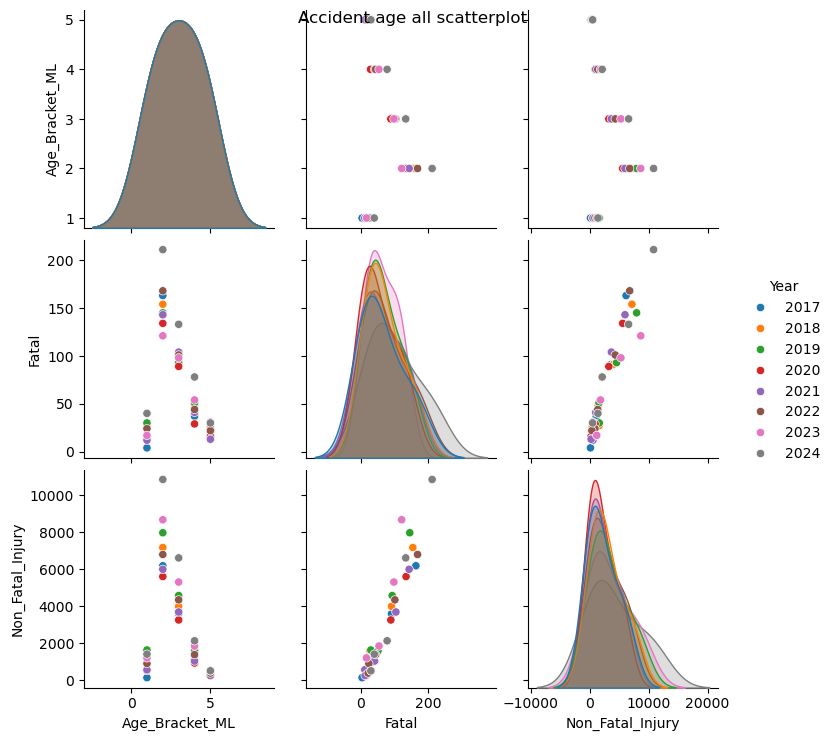

In [6]:
plt.figure(figsize=(18, 10))
sns.pairplot(df[['Age_Bracket_ML','Fatal','Non_Fatal_Injury']+['Year']],
             diag_kind='kde',
             hue='Year',
            palette = 'tab10')
plt.suptitle('Accident age all scatterplot')
plt.savefig('Accident age all scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

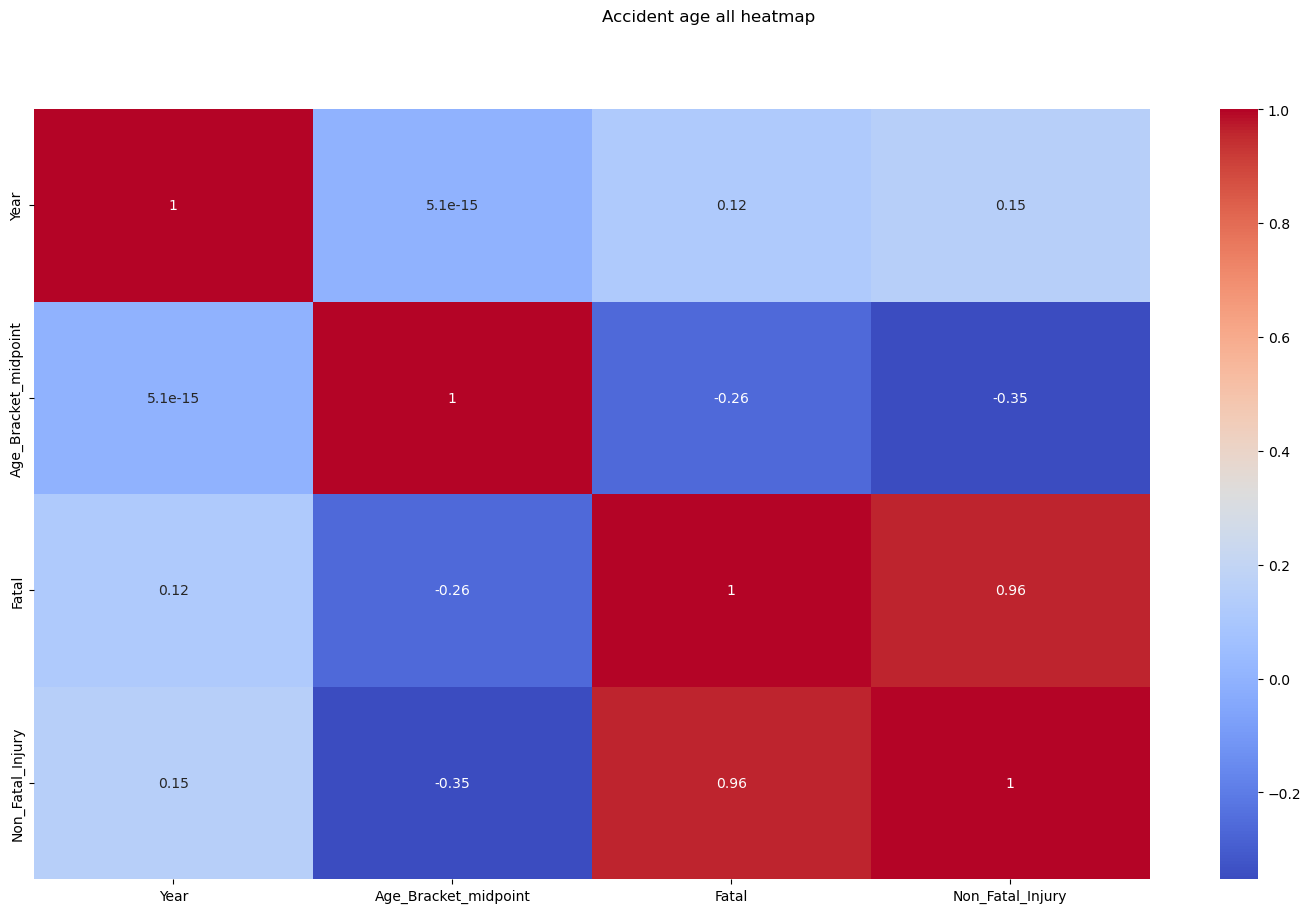

In [7]:
plt.figure(figsize=(18, 10))
sns.heatmap(df[['Year','Age_Bracket_midpoint','Fatal','Non_Fatal_Injury']].corr(), annot=True,cmap='coolwarm')
plt.suptitle('Accident age all heatmap')
plt.savefig('Accident age all heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
def skew_check(dataset,val):
    print("Skewness Check:")
    for col in val:
        skew = dataset[col].skew()
        print(f"{col:10s}: {skew:6.2f} {'TRANSFORM' if abs(skew) > 1 else 'OK'}")

skew_check(df,['Fatal','Non_Fatal_Injury'])
df['Non_Fatal_Injury_sqrt'] = np.sqrt(df['Non_Fatal_Injury'])
skew_check(df,['Fatal','Non_Fatal_Injury_sqrt'])

Skewness Check:
Fatal     :   0.82 OK
Non_Fatal_Injury:   1.05 TRANSFORM
Skewness Check:
Fatal     :   0.82 OK
Non_Fatal_Injury_sqrt:   0.48 OK


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Fatal'}>],
       [<Axes: title={'center': 'Non_Fatal_Injury'}>,
        <Axes: title={'center': 'Age_Bracket_midpoint'}>],
       [<Axes: title={'center': 'Age_Bracket_ML'}>,
        <Axes: title={'center': 'Non_Fatal_Injury_sqrt'}>]], dtype=object)

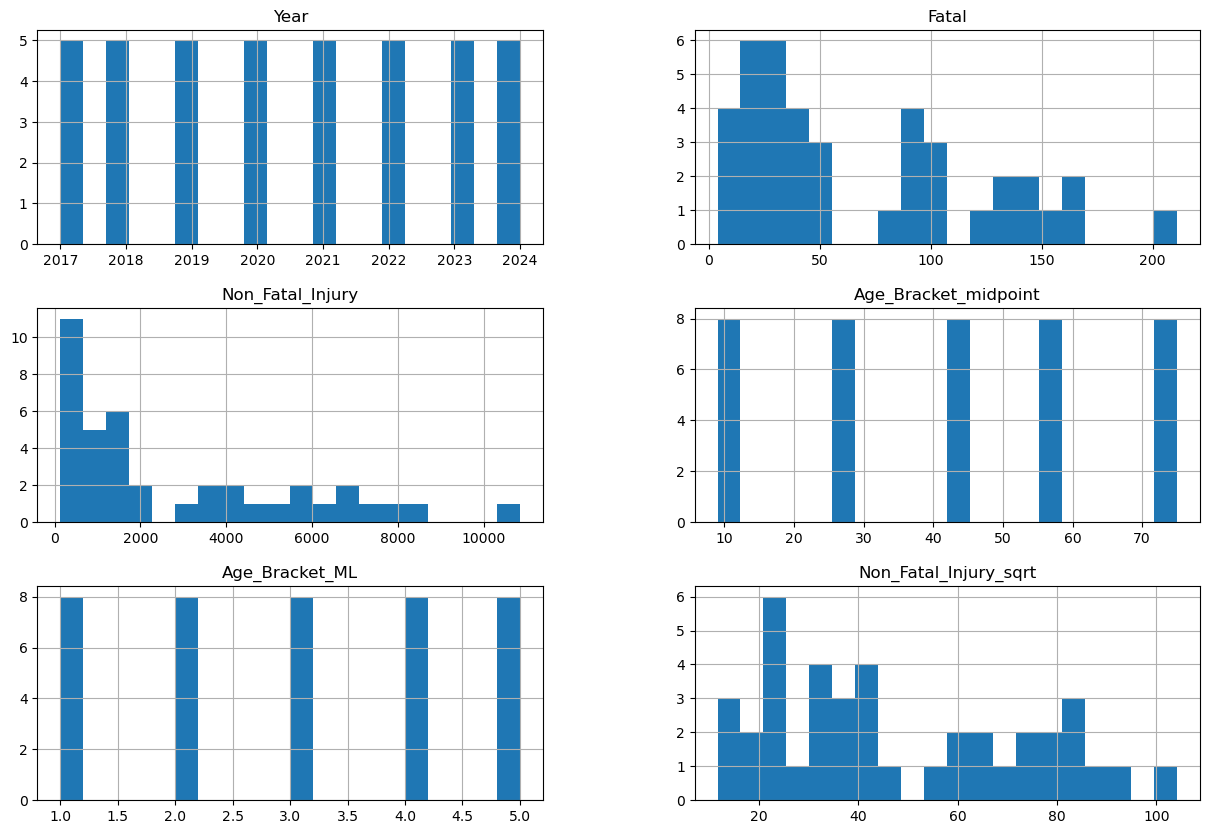

In [19]:
df.hist(figsize=(15, 10), bins=20)

In [9]:
df.to_csv('Accident age.csv', index=False)